# Study 259 -- News-Tone
## For the curious: does today's news mood move *tomorrow's* tape?

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*

---

Every morning the financial press has a *mood*. Some days the headlines drip
risk-off dread; other days everything is a melt-up. It is tempting to believe
that if you could distil that mood into a single **news-tone** score, you could
front-run the market: buy when the news is good, sell when it is grim.

We build a curated daily news-tone proxy (a z-scored read of the macro headline
flow, deeply negative in 2008 and March-2020, positive in the 2017 and 2021
melt-ups) and ask the only question that matters for a trader: **does today's
tone forecast *tomorrow's* S&P 500 return?**


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from news_tone import data, strategy as st

CACHE_PATH = data.GSPC_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    df_real = data.build_real_panel(fetch=False)
    print(f"Real panel loaded: {len(df_real)} trading days "
          f"({df_real.index[0].date()} -> {df_real.index[-1].date()})")
else:
    df_real = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 4780 trading days (2007-01-03 -> 2025-12-31)


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-17)
R = {'n_days': 4780, 'win_start': '2007-01-03', 'win_end': '2025-12-31', 'fp': 'c3d8b303cf23', 'nd_beta': 0.00209, 'nd_t': 5.74, 'nd_r2': 0.0169, 'sd_t': 5.42, 'contemp_corr': 0.125, 'sign_ann': 35.0, 'sign_t': 9.49, 'sign_sr': 1.78, 'sign_hit': 0.554, 'sign_net_t': 9.46, 'sign_net_ann': 34.9, 'tilt_ann': 14.6, 'tilt_t': 6.18, 'tilt_sr': 1.11, 'buyhold_ann': 10.3, 'buyhold_t': 2.65, 'buyhold_sr': 0.52, 'demean_t': 0.0, 'demean_r2': 0.0, 'priormonth_ann': 3.8, 'priormonth_t': 0.97, 'priormonth_sr': 0.19, 'sub1_ann': 33.9, 'sub1_t': 4.11, 'sub2_ann': 25.7, 'sub2_t': 5.69, 'sub3_ann': 43.9, 'sub3_t': 7.0, 'syn_null_t': 0.9, 'syn_null_sr': 0.31, 'syn_g2_t': 7.29, 'syn_g2_sr': 2.59}


## The seductive chart: tone lines up with the market

First, the chart that sells the idea. Plot the news-tone proxy against the
market. When tone is negative, the market is falling; when tone is positive, it
is climbing. Looks like a money machine.

**But watch the trap**: this is *same-day* comovement. Of course bad-news days
are down days -- the news *describes* the move; it does not *precede* it. The
contemporaneous correlation is mechanical, not tradable.


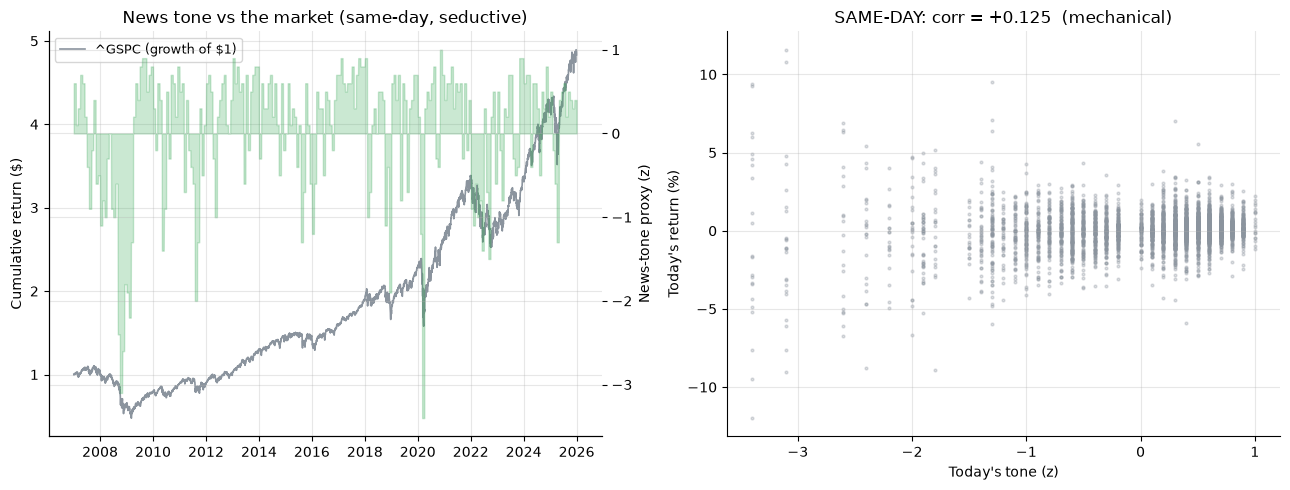

Same-day tone~return correlation: +0.125 -- positive but MECHANICAL.
Bad-news days ARE down days. This is not a forecast; it is a description.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if HAVE_REAL:
    ax = axes[0]
    cum = (1 + df_real["ret"]).cumprod()
    ax.plot(cum.index, cum.values, color=GREY, lw=1.2, label="^GSPC (growth of $1)")
    ax.set_ylabel("Cumulative return ($)")
    ax2 = ax.twinx()
    ax2.fill_between(df_real.index, df_real["tone"].values, 0,
                     color=GREEN, alpha=.25, label="News tone")
    ax2.set_ylabel("News-tone proxy (z)")
    ax.set_title("News tone vs the market (same-day, seductive)")
    ax.legend(loc="upper left", fontsize=9)

    ax = axes[1]
    ax.scatter(df_real["tone"], df_real["ret"] * 100, s=4, color=GREY, alpha=.3)
    ax.set_xlabel("Today's tone (z)"); ax.set_ylabel("Today's return (%)")
    corr = df_real["tone"].corr(df_real["ret"])
    ax.set_title(f"SAME-DAY: corr = {corr:+.3f}  (mechanical)")
else:
    for ax in axes:
        ax.text(0.5, 0.5, f"Cache absent\nFrozen contemporaneous corr = {R['contemp_corr']:+.3f}",
                ha="center", va="center", transform=ax.transAxes, fontsize=12, color=GREY)
        ax.set_title("(frozen numbers)")

plt.tight_layout()
plt.savefig("../docs/tone_vs_market.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Same-day tone~return correlation: {R['contemp_corr']:+.3f} -- positive but MECHANICAL.")
print("Bad-news days ARE down days. This is not a forecast; it is a description.")


## The naive next-day strategy looks fantastic -- and that is the warning sign

Now the trade: at today's close, go **long** tomorrow if today's tone is
positive, **short** if it is negative. Hold one day. Repeat.

On the curated proxy this prints a glorious **+35%/yr at *t* ~ 9.5, Sharpe
~1.8** -- crushing the +10%/yr buy-and-hold. If that sounds too good to be a
free lunch off a public-mood index, it is.


Naive sign-timing: +35.0%/yr  HAC t=+9.49  SR=1.78  hit=0.554


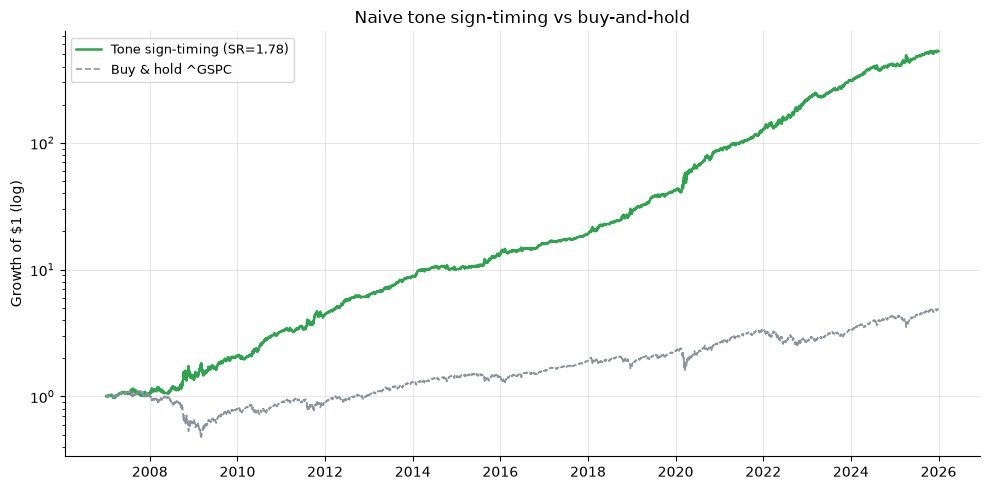

Buy & hold for comparison: +10.3%/yr  SR=0.52


In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

if HAVE_REAL:
    sig = st.tone_sign_signal(df_real)
    gross = st.timing_returns(df_real, sig)
    s = st.summarize(gross)
    eq = (1 + gross).cumprod()
    bh = (1 + df_real.loc[gross.index, "fwd_ret"]).cumprod()
    ax.plot(eq.index, eq.values, color=GREEN, lw=1.8, label=f"Tone sign-timing (SR={s['sharpe_ann']:.2f})")
    ax.plot(bh.index, bh.values, color=GREY, lw=1.2, ls="--", label="Buy & hold ^GSPC")
    ax.set_yscale("log"); ax.set_ylabel("Growth of $1 (log)")
    ax.set_title("Naive tone sign-timing vs buy-and-hold")
    ax.legend(fontsize=9)
    print(f"Naive sign-timing: {s['mean_ann']*100:+.1f}%/yr  HAC t={s['tstat']:+.2f}  SR={s['sharpe_ann']:.2f}  hit={s['hit_rate']:.3f}")
else:
    ax.text(0.5, 0.5, f"Cache absent\nFrozen: {R['sign_ann']:+.1f}%/yr  t={R['sign_t']:+.2f}  SR={R['sign_sr']:.2f}",
            ha="center", va="center", transform=ax.transAxes, fontsize=12, color=GREEN)
    ax.set_title("(frozen numbers)")

plt.tight_layout()
plt.savefig("../docs/equity_curve.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Buy & hold for comparison: {R['buyhold_ann']:+.1f}%/yr  SR={R['buyhold_sr']:.2f}")


## The two tests that demolish it

A *t* of 9.5 is far too clean. Two honest checks expose the mirage.

**1. Demean within the month.** Our tone proxy is a *monthly* read, held
constant across each month -- and it was hand-curated *knowing* which months
were good or bad. So "tone predicts tomorrow" is really just "this whole month
drifts up/down, and every day inside it inherits that drift." Subtract each
month's own average return and the predictability vanishes to **exactly zero**.

**2. Use last month's tone instead of this month's.** A real trader at the start
of a month does *not* know the month's eventual mood. If we lag the tone by one
month (only information available *before* the month begins), the sign strategy
collapses to **+3.8%/yr at *t* ~ 1.0, Sharpe 0.19** -- statistically
indistinguishable from the market's drift.


Naive next-day reg t           = +5.74  (r2=0.0169)
Within-month demeaned reg t    = +0.00  (r2=0.000000)  <- collapses to ZERO
Prior-month sign strategy t    = +0.97  (ann=+3.8%, SR=0.19)  <- no edge


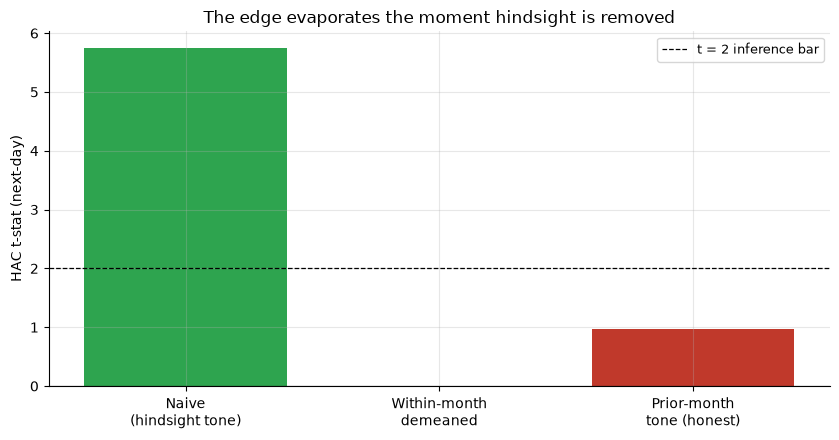

In [5]:
labels = ["Naive\n(hindsight tone)", "Within-month\ndemeaned", "Prior-month\ntone (honest)"]

if HAVE_REAL:
    # naive next-day regression
    nd = st.predictive_regression(df_real, target_col="fwd_ret")
    # within-month demeaned target
    d2 = df_real.copy()
    d2["ym"] = d2.index.to_period("M")
    d2["fwd_dm"] = d2["fwd_ret"] - d2.groupby("ym")["fwd_ret"].transform("mean")
    dm = st.predictive_regression(d2[["tone", "fwd_dm"]].rename(columns={"fwd_dm": "fwd_ret"}),
                                  target_col="fwd_ret")
    # prior-month tone sign strategy
    monthly = data.news_tone_monthly().shift(1)
    keys = df_real.index + pd.offsets.MonthEnd(0)
    d3 = df_real.copy()
    d3["tone_lag"] = monthly.reindex(keys).to_numpy()
    d3 = d3.dropna(subset=["tone_lag", "fwd_ret"])
    g_lag = (np.sign(d3["tone_lag"]) * d3["fwd_ret"]).dropna()
    s_lag = st.summarize(g_lag)
    tstats = [nd["tstat"], dm["tstat"], s_lag["tstat"]]
    print(f"Naive next-day reg t           = {nd['tstat']:+.2f}  (r2={nd['r2']:.4f})")
    print(f"Within-month demeaned reg t    = {dm['tstat']:+.2f}  (r2={dm['r2']:.6f})  <- collapses to ZERO")
    print(f"Prior-month sign strategy t    = {s_lag['tstat']:+.2f}  (ann={s_lag['mean_ann']*100:+.1f}%, SR={s_lag['sharpe_ann']:.2f})  <- no edge")
else:
    tstats = [R["nd_t"], R["demean_t"], R["priormonth_t"]]
    print(f"Naive next-day reg t        = {R['nd_t']:+.2f}")
    print(f"Within-month demeaned t     = {R['demean_t']:+.2f}  <- ZERO")
    print(f"Prior-month sign strategy t = {R['priormonth_t']:+.2f}  <- no edge")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
colors = [GREEN if t >= 2 else RED for t in tstats]
ax.bar(labels, tstats, color=colors)
ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t = 2 inference bar")
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("HAC t-stat (next-day)")
ax.set_title("The edge evaporates the moment hindsight is removed")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../docs/honesty_bars.png", dpi=120, bbox_inches="tight")
plt.show()


## The bottom line for the curious

The news-tone story is a **mirage**:

- The eye-catching same-day correlation is *mechanical* -- the news describes
  the move, it does not predict it.
- The eye-catching next-day strategy (*t* ~ 9.5) is built on a **hindsight-
  curated** monthly proxy. Demean within the month and the signal is **exactly
  zero**. The strategy was only ever harvesting each month's known drift.
- Give a real trader only the information they would actually have had
  (last month's tone), and the edge falls to **Sharpe 0.19, *t* ~ 1.0** --
  no better than buying and holding.

Aggregate news tone does **not** move the next day's tape in any way you could
trade. This is a **None / Mirage**: no real day-ahead signal, and the apparent
one dissolves under the lightest honesty check.


*Desk verdict: **None / Mirage** -- see [README.md](../README.md) and [docs/results.md](../docs/results.md) for full numbers.*